In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [7]:

plt.style.use('default')
sns.set_palette("husl")

In [8]:
df = pd.read_excel('marketing_campaign.xlsx')

In [9]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [11]:
df.fillna(0, inplace=True)

In [12]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [37]:
df.duplicated().sum()

np.int64(0)

Luego de organizar y limpiar nuestro Datasets, procedemos a relacionar los valores necesarios para realizar nuestro analisis.

In [13]:
agrupacion_gastos = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['TotalGastos'] = agrupacion_gastos

Preparación de datos

Agrupamos todas las variables de gasto (MntWines, MntFruits, etc.) en un nuevo campo: TotalGastos.

Ahora contamos con dos variables clave para el análisis: Income (ingresos) y TotalGastos (gasto total).


Visualización de datos de Ingresos y Gastos Totales

        Income  TotalGastos
0          0.0        11709
1       1730.0            8
2       2447.0         1730
3       3502.0            5
4       4023.0            9
...        ...          ...
1970  157243.0         1608
1971  157733.0           59
1972  160803.0         1717
1973  162397.0          107
1974  666666.0           62

[1975 rows x 2 columns]


Relación de datos de Ingresos y Gastos Totales



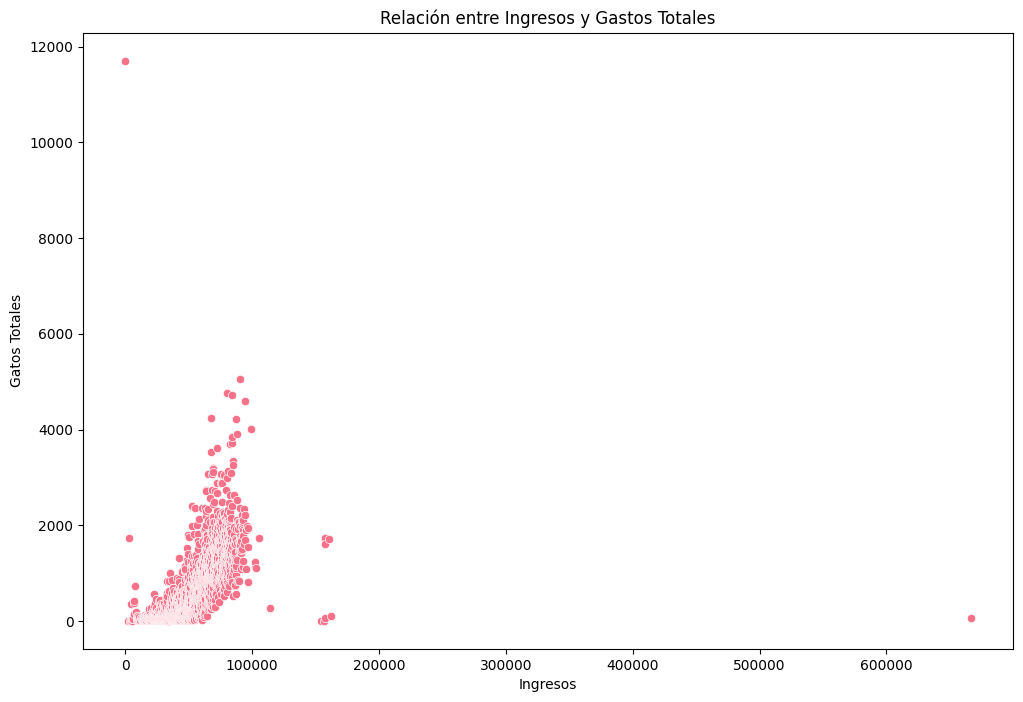

In [40]:
gastos_por_ingresos = df.groupby('Income')['TotalGastos'].sum().reset_index()
print("Visualización de datos de Ingresos y Gastos Totales\n")
print(gastos_por_ingresos)
print("\n")
print("Relación de datos de Ingresos y Gastos Totales\n")
plt.figure(figsize=(12,8))
sns.scatterplot(data=gastos_por_ingresos, x= 'Income', y='TotalGastos')
plt.title('Relación entre Ingresos y Gastos Totales')
plt.xlabel('Ingresos')
plt.ylabel('Gatos Totales')
plt.show()

Relación Ingresos vs. Gasto_Total

En la muestra hay clientes con ingresos altos que efectivamente gastan más, pero también aparecen casos de ingresos medios que mantienen altos niveles de gasto (ejemplo: algunos clientes entre 40k y 90k de ingresos figuran entre los mayores consumidores).

También se observa que no todos los clientes de alto ingreso son los que más gastan: hay casos con ingresos sobre 150k pero con gasto relativamente bajo.

Visualización de los 10 mayores consumidores

         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
1572   5350        1991      Master         Single  90638.0        0   
1179   5735        1991      Master         Single  90638.0        0   
1492   1763        1988  Graduation       Together  87679.0        0   
987    4580        1969  Graduation        Married  75759.0        0   
1052   4475        1949         PhD        Married  69098.0        0   
1601   5453        1956      Master        Married  90226.0        0   
1458  10133        1970  Graduation         Single  93790.0        0   
1288   9010        1972      Master        Married  83151.0        0   
1301   6024        1953  Graduation       Together  94384.0        0   
943    5386        1953  Graduation       Together  94384.0        0   

      Teenhome Dt_Customer  Recency  MntWines  ...  AcceptedCmp3  \
1572         0  2014-02-13       29      1156  ...             0   
1179         0  2014-02-1

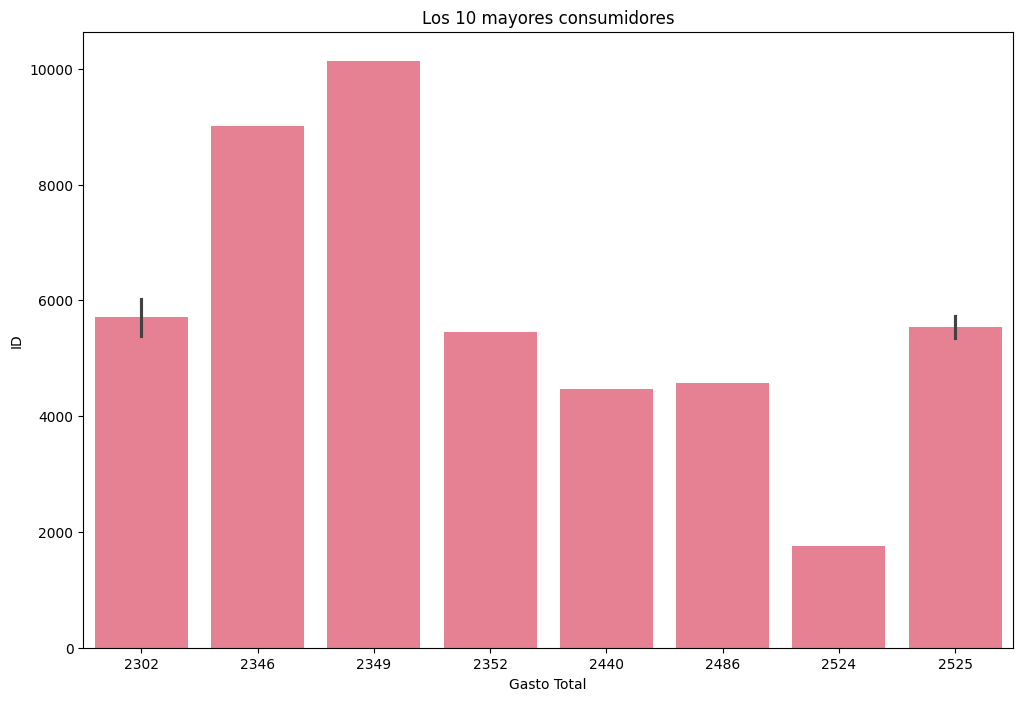

In [19]:
mayores_consumidores = df.sort_values(by='TotalGastos', ascending=False).head(10)
print("Visualización de los 10 mayores consumidores\n")
print(mayores_consumidores)
plt.figure(figsize=(12,8))
sns.barplot(data=mayores_consumidores, x='TotalGastos', y='ID')
plt.title('Los 10 mayores consumidores')
plt.xlabel('Gasto Total')
plt.ylabel('ID')
plt.show()

Visualización del enfoque de clientes con menor gasto

         ID  Year_Birth   Education Marital_Status    Income  Kidhome  \
1524  11110        1973  Graduation         Single    3502.0        1   
655    5555        1975  Graduation       Divorced  153924.0        0   
981    3955        1965  Graduation       Divorced    4861.0        0   
1420   5824        1972         PhD       Together   34578.0        2   
2129  10104        1974  Graduation       Together   33590.0        2   
1245   6862        1971  Graduation       Divorced    1730.0        0   
2132  11181        1949         PhD        Married  156924.0        0   
1846   9931        1963         PhD        Married    4023.0        1   
1819   8566        1961         PhD       Together   32583.0        1   
1248   4298        1973         PhD       Together   20427.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  AcceptedCmp3  \
1524         0  2013-04-13       56         2  ...             0   
655  

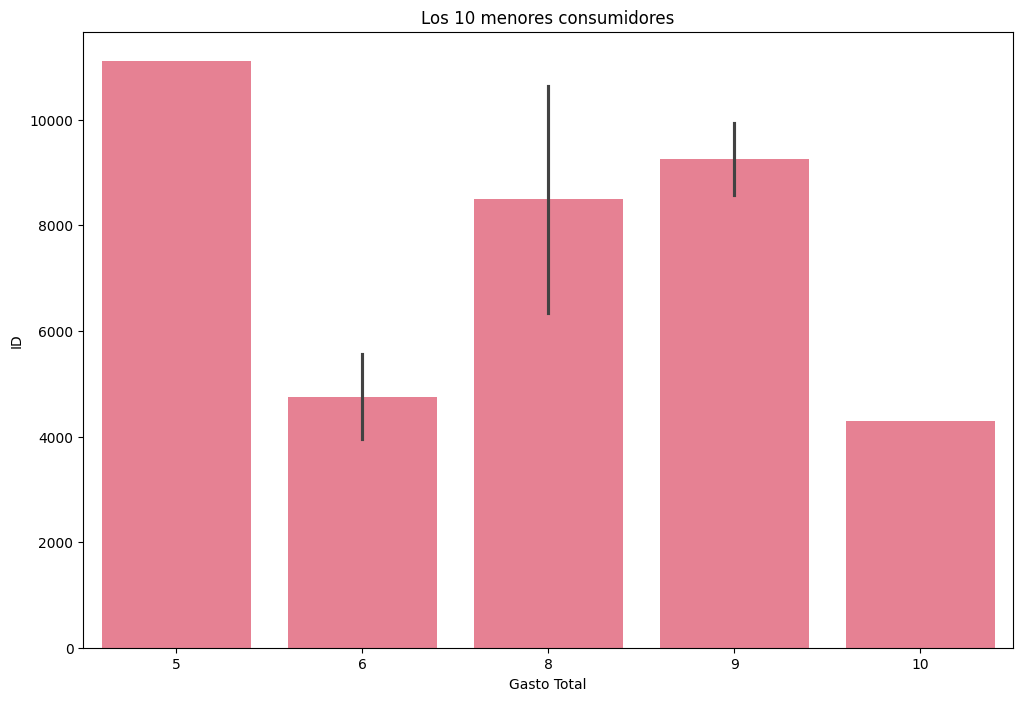

In [41]:
clientes_con_menor_gasto = df.sort_values(by='TotalGastos', ascending=True).head(10)
print("Visualización del enfoque de clientes con menor gasto\n")
print(clientes_con_menor_gasto)
plt.figure(figsize=(12,8))
sns.barplot(data=clientes_con_menor_gasto, x='TotalGastos', y='ID')
plt.title('Los 10 menores consumidores')
plt.xlabel('Gasto Total')
plt.ylabel('ID')
plt.show()


Segmentos eficientes

Visualizamos mediante un Top 10 consumidores que  pertenecen al rango de ingresos altos-medios (70k–90k), lo que confirma la hipótesis de “segmentos medios con eficiencia de compra”.

En el análisis de clientes con menor gasto, aparecen tanto ingresos bajos como altos, lo que refuerza la idea de que no siempre más ingreso = más consumo.

Elasticidad del consumo: Existe una relación positiva entre ingresos y gasto, pero no es lineal.

Oportunidad de estrategia:

Basado en nuestro analisis nuestro trabajo es no solo enfocarnos en clientes con mayores ingresos, sino considerar otros segmentos de rango intermedios.

Los segmentos medios con alto gasto son muy valiosos y podrían ser un objetivo más rentable.

Esto sugiere a mediano plazo diseñar campañas diferenciadas:

Premium: reforzar fidelización en clientes de ingresos altos que sí gastan mucho.

Eficientes: captar y retener clientes de ingresos medios que maximizan su gasto relativo.

De manera proactiva, identificamos por valores especificos el total de gastos según nivel educativo, y en otro analisis debajo por estado o situación sentimental.

Visualización de datos de Gastos Totales por Educación

    Education  TotalGastos
0    2n Cycle       100795
1       Basic         4417
2  Graduation       698626
3      Master       226359
4         PhD       326791


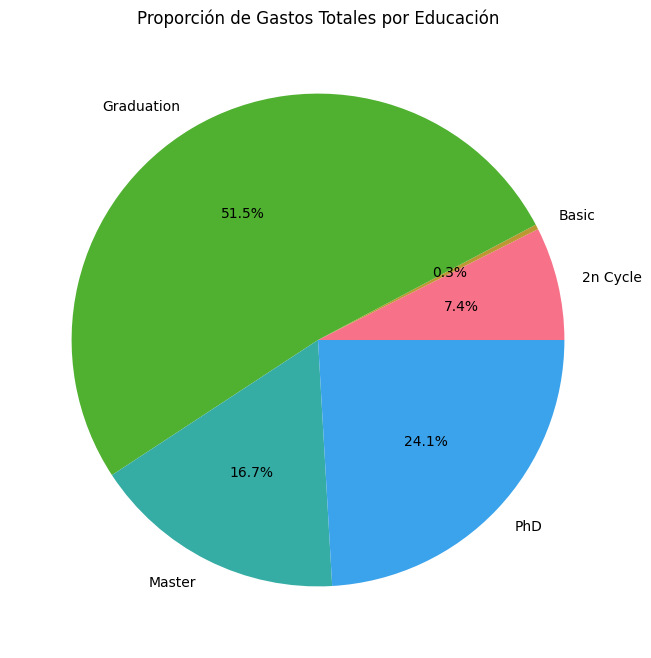

In [17]:
gastos_por_educacion = df.groupby('Education')['TotalGastos'].sum().reset_index()
print("Visualización de datos de Gastos Totales por Educación\n")
print(gastos_por_educacion)
plt.figure(figsize=(12,8))
plt.pie(gastos_por_educacion['TotalGastos'], labels=gastos_por_educacion['Education'], autopct='%1.1f%%')
plt.title('Proporción de Gastos Totales por Educación')
plt.show()


Visualización de datos de Gastos Totales por Situación Sentimental

  Marital_Status  TotalGastos
0         Absurd         2385
1          Alone          770
2       Divorced       141666
3        Married       510453
4         Single       291112
5       Together       352865
6          Widow        56889
7           YOLO          848


Text(0.5, 0, 'Situación Sentimental')

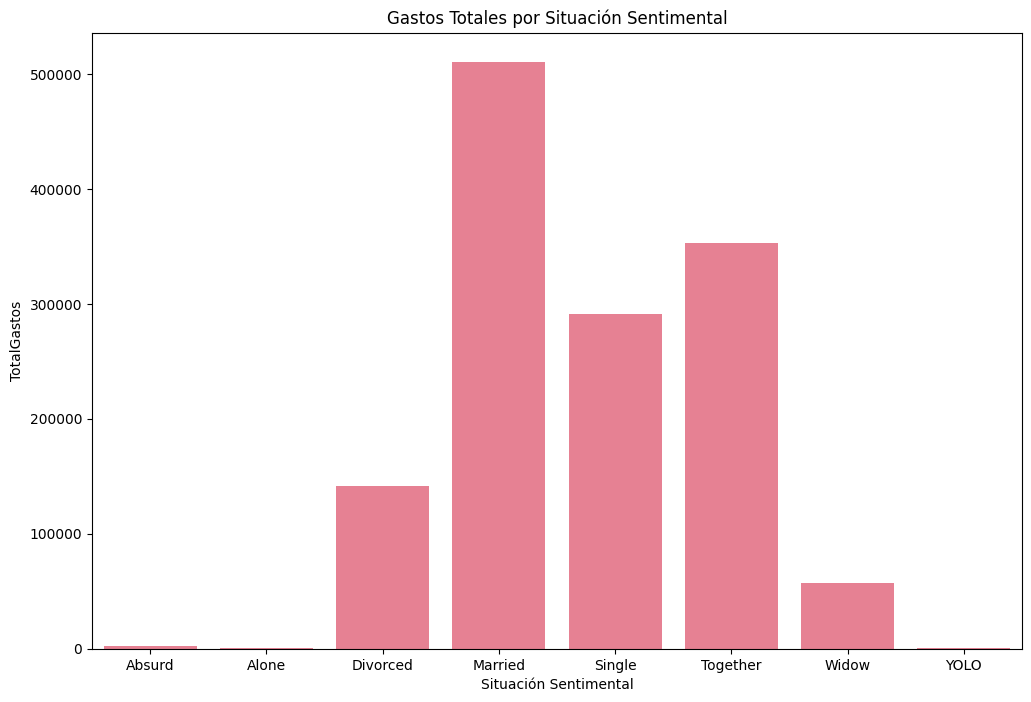

In [18]:
gastos_por_situacion_sentimental = df.groupby('Marital_Status')['TotalGastos'].sum().reset_index()
print("Visualización de datos de Gastos Totales por Situación Sentimental\n")
print(gastos_por_situacion_sentimental)
plt.figure(figsize=(12,8))
sns.barplot(data=gastos_por_situacion_sentimental, x='Marital_Status', y='TotalGastos')
plt.title('Gastos Totales por Situación Sentimental')
plt.xlabel('Situación Sentimental')